In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
datapath = "/content/drive/MyDrive/archive (1)/Brain MRI"
train_datagen = ImageDataGenerator(
       rescale=1./255,
       shear_range=0.2,
       zoom_range=0.2,
       horizontal_flip=True,
       validation_split=0.2
   )
train_data = train_datagen.flow_from_directory(datapath,
                                           target_size=(224,224),
                                           batch_size=45,
                                           class_mode='categorical',
                                           subset='training')
test_data = train_datagen.flow_from_directory(datapath,
                                           target_size=(224,224),
                                           batch_size=45,
                                           class_mode='categorical',
                                           subset='validation')

Found 54 images belonging to 2 classes.
Found 12 images belonging to 2 classes.


In [25]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(2, activation='softmax'))

In [26]:
optimizer = RMSprop(learning_rate=0.00001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
history = model.fit(train_data, epochs=50, validation_data=test_data)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 7s/step - accuracy: 0.5062 - loss: 0.6983 - val_accuracy: 0.5000 - val_loss: 0.6838
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 6s/step - accuracy: 0.5309 - loss: 0.6860 - val_accuracy: 0.5000 - val_loss: 0.6758
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4988 - loss: 0.6852 - val_accuracy: 0.6667 - val_loss: 0.6733
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5926 - loss: 0.6785 - val_accuracy: 0.5000 - val_loss: 0.6629
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5432 - loss: 0.6789 - val_accuracy: 0.5833 - val_loss: 0.6626
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5284 - loss: 0.6751 - val_accuracy: 0.5000 - val_loss: 0.6499
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5358 - loss: 0.6715 - val_accuracy: 0.5833 - val_loss: 0.6545
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5160 - loss: 0.6722 - val_accuracy: 0.6667 - val_loss: 0.6423
Epoch 9/50


In [27]:




model.evaluate(test_data)



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step - accuracy: 1.0000 - loss: 0.4604


[0.46035924553871155, 1.0]

Enter the path of the image: /content/drive/MyDrive/archive (2)/brain_tumor_dataset/brain_tumor_classification/Testing/pituitary_tumor/image(15).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
There is a brain tumor


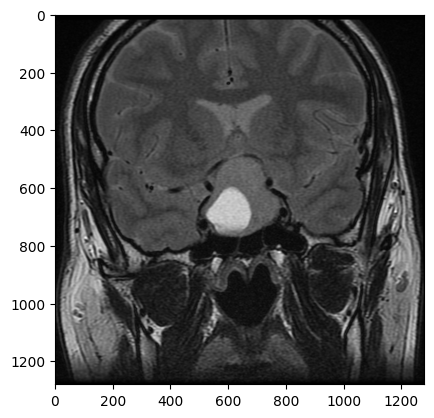

In [39]:
labels = train_data.class_indices
labels
Image_Path = input("Enter the path of the image: ")
img = image.load_img(Image_Path, target_size=(224,224))
picture = cv2.imread(Image_Path)

prediction = image.img_to_array(img)
prediction = prediction/255
prediction = np.expand_dims(prediction, axis=0)
prediction = model.predict(prediction)
prediction
if prediction[0][0] > prediction[0][1]:
  print("There is no brain tumor")
else:
  print("There is a brain tumor")
plt.imshow(picture)

In [45]:
with open('Brain_tumor_yes_or_no_model.json', 'w') as f:
    f.write(model.to_json())
# Change the filename to end with .weights.h5
model.save_weights('model.weights.h5')
print("successful")

successful


In [46]:
import os

# Define the directory path
save_dir = '/content/drive/My Drive/MyModels'

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Define the path to save the model in Google Drive
save_path = os.path.join(save_dir, 'model.weights.h5') # Use os.path.join for platform compatibility

# Save the model weights to the specified path
model.save_weights(save_path)
print("Model saved to Google Drive successfully!")

Model saved to Google Drive successfully!
